In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_colwidth', 100)

In [3]:
df=pd.read_csv("Reviews.csv")

In [4]:
df.shape

(568454, 10)

In [5]:
df.columns

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')

In [6]:
df.isna().sum()

Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64

In [7]:
df.isna().sum().sum()

np.int64(53)

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

Id                         int64
ProductId                 object
UserId                    object
ProfileName               object
HelpfulnessNumerator       int64
HelpfulnessDenominator     int64
Score                      int64
Time                       int64
Summary                   object
Text                      object
dtype: object

In [10]:
# Check duplicate reviews (same user, same product, same text)
duplicates = df.duplicated(subset=['UserId', 'ProfileName', 'Time', 'Text'])
print(f"Total duplicate rows: {duplicates.sum()}")

Total duplicate rows: 174521


In [11]:
# Remove duplicates
df = df.drop_duplicates(subset=['UserId', 'ProfileName', 'Time', 'Text'])

# Fill nulls instead of dropping
df['ProfileName'] = df['ProfileName'].fillna('Unknown')
df['Summary'] = df['Summary'].fillna('')

# Confirm cleaned shape
print(f"Cleaned dataset shape: {df.shape}")


Cleaned dataset shape: (393933, 10)


C:\Users\pragy\AppData\Local\Temp\ipykernel_14200\4143457182.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Score', data=df, palette='viridis')


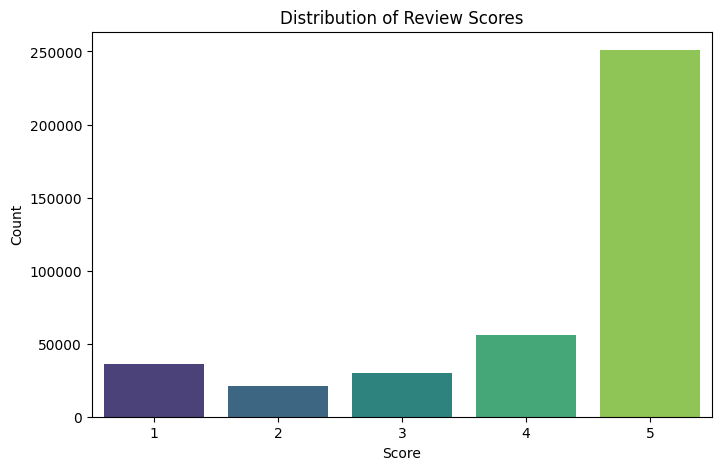

Score
5    250962
4     56094
1     36306
3     29769
2     20802
Name: count, dtype: int64


In [12]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Score', data=df, palette='viridis')
plt.title('Distribution of Review Scores')
plt.xlabel('Score')
plt.ylabel('Count')
plt.show()

# Exact numbers
print(df['Score'].value_counts())

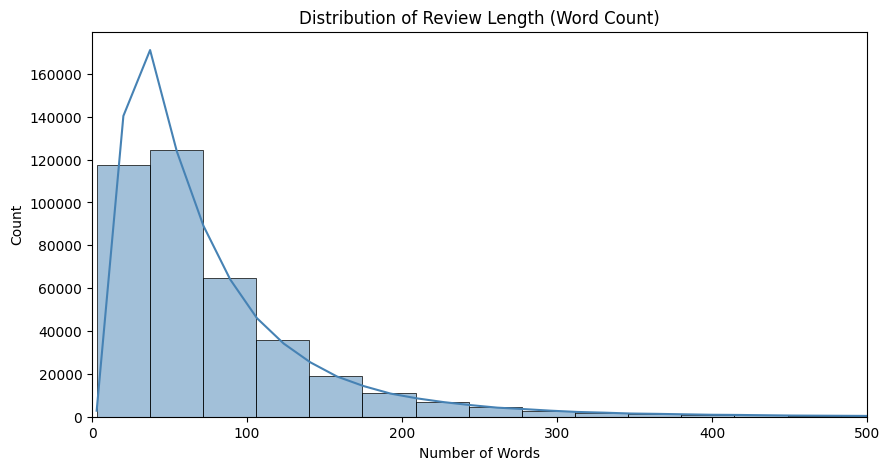

count    393933.000000
mean         79.830712
std          77.258309
min           3.000000
25%          34.000000
50%          57.000000
75%          98.000000
max        3432.000000
Name: review_length, dtype: float64


In [13]:
# Add a column for review length
df['review_length'] = df['Text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 5))
sns.histplot(df['review_length'], bins=100, kde=True, color='steelblue')
plt.title('Distribution of Review Length (Word Count)')
plt.xlabel('Number of Words')
plt.ylabel('Count')
plt.xlim(0, 500)
plt.show()

print(df['review_length'].describe())

C:\Users\pragy\AppData\Local\Temp\ipykernel_14200\1826959711.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Score', y='review_length', data=df, palette='viridis')


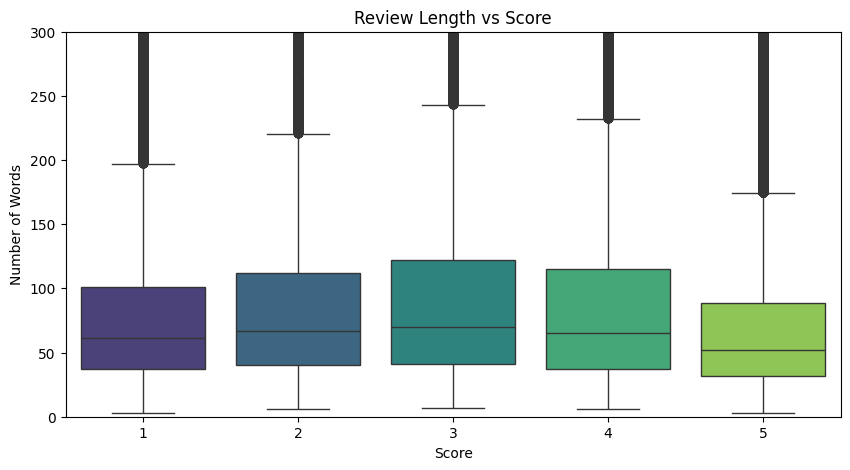

In [14]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='Score', y='review_length', data=df, palette='viridis')
plt.title('Review Length vs Score')
plt.xlabel('Score')
plt.ylabel('Number of Words')
plt.ylim(0, 300)
plt.show()

"Negative reviews (1–2 star) tend to be longer and more detailed than positive reviews (5 star), suggesting dissatisfied customers provide richer feedback for product improvement."

Score
1    0.412004
2    0.372350
3    0.356153
4    0.387981
5    0.436447
Name: helpfulness_ratio, dtype: float64


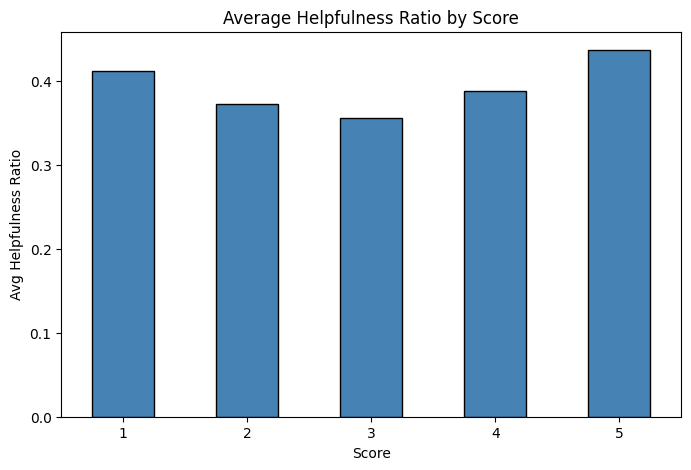

In [15]:
# Calculate helpfulness ratio (avoid division by zero)
df['helpfulness_ratio'] = df.apply(
    lambda x: x['HelpfulnessNumerator'] / x['HelpfulnessDenominator']
    if x['HelpfulnessDenominator'] > 0 else 0, axis=1
)

# Average helpfulness by score
helpfulness_by_score = df.groupby('Score')['helpfulness_ratio'].mean()
print(helpfulness_by_score)

plt.figure(figsize=(8, 5))
helpfulness_by_score.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Average Helpfulness Ratio by Score')
plt.xlabel('Score')
plt.ylabel('Avg Helpfulness Ratio')
plt.xticks(rotation=0)
plt.show()



"Readers find extreme reviews (1 and 5 star) significantly more helpful than neutral ones, suggesting polarised opinions drive purchase decisions more than balanced assessments."

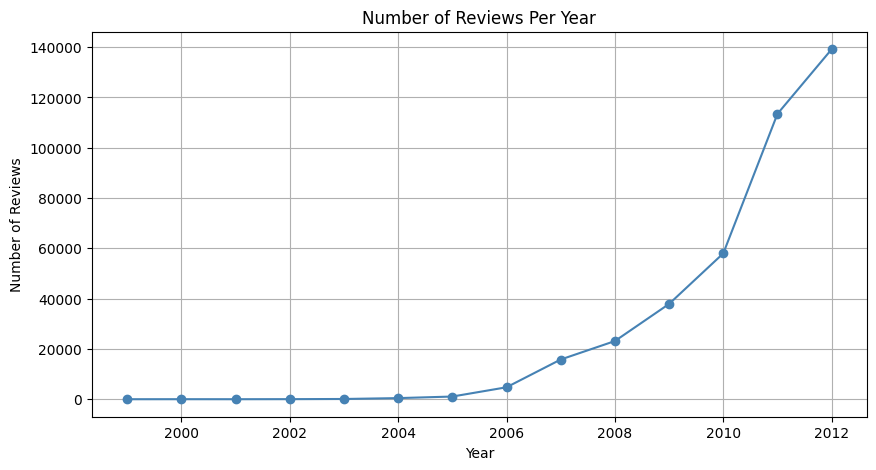

Year
1999         4
2000        17
2001         8
2002        33
2003        99
2004       445
2005      1069
2006      4749
2007     15795
2008     23134
2009     37896
2010     58003
2011    113495
2012    139186
dtype: int64


In [16]:
# Convert Unix timestamp to datetime
df['Time'] = pd.to_datetime(df['Time'], unit='s')
df['Year'] = df['Time'].dt.year

# Reviews per year
reviews_per_year = df.groupby('Year').size()

plt.figure(figsize=(10, 5))
reviews_per_year.plot(kind='line', marker='o', color='steelblue')
plt.title('Number of Reviews Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Reviews')
plt.grid(True)
plt.show()

print(reviews_per_year)

"Amazon Fine Food review volume grew exponentially — from just 4 reviews in 1999 to 139,186 in 2012 — reflecting the broader shift in consumer behaviour toward online product research before purchase."

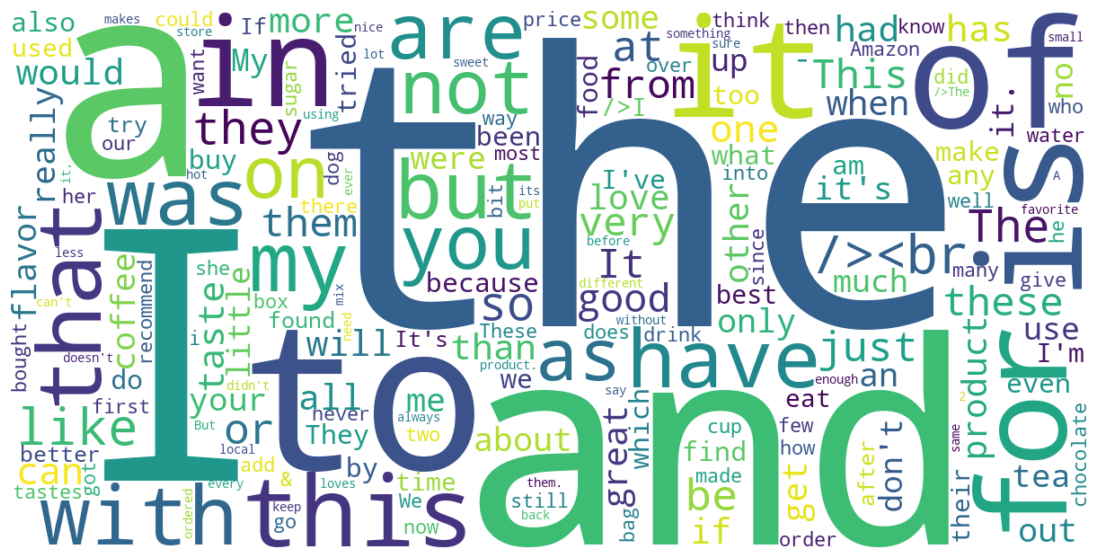

In [17]:
from collections import Counter
from wordcloud import WordCloud

counter = Counter()

for text in df['Text'].dropna():
    words = str(text).split()
    counter.update(words)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    max_words=200
).generate_from_frequencies(counter)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [18]:
import re

def clean_text(text):
    text = str(text)
    text = re.sub(r'<.*?>', ' ', text)        # Remove HTML tags like <br>
    text = re.sub(r'&amp;|&lt;|&gt;', ' ', text)  # Remove HTML entities
    text = re.sub(r'[^a-zA-Z\s]', '', text)   # Remove punctuation & numbers
    text = text.lower().strip()                # Lowercase & trim whitespace
    text = re.sub(r'\s+', ' ', text)           # Remove extra spaces
    return text

# Apply to both Text and Summary columns
df['cleaned_text'] = df['Text'].apply(clean_text)
df['cleaned_summary'] = df['Summary'].apply(clean_text)

# Verify - compare before and after
print("BEFORE:", df['Text'].iloc[0][:200])
print("\nAFTER:", df['cleaned_text'].iloc[0][:200])

BEFORE: I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labrador

AFTER: i have bought several of the vitality canned dog food products and have found them all to be of good quality the product looks more like a stew than a processed meat and it smells better my labrador i


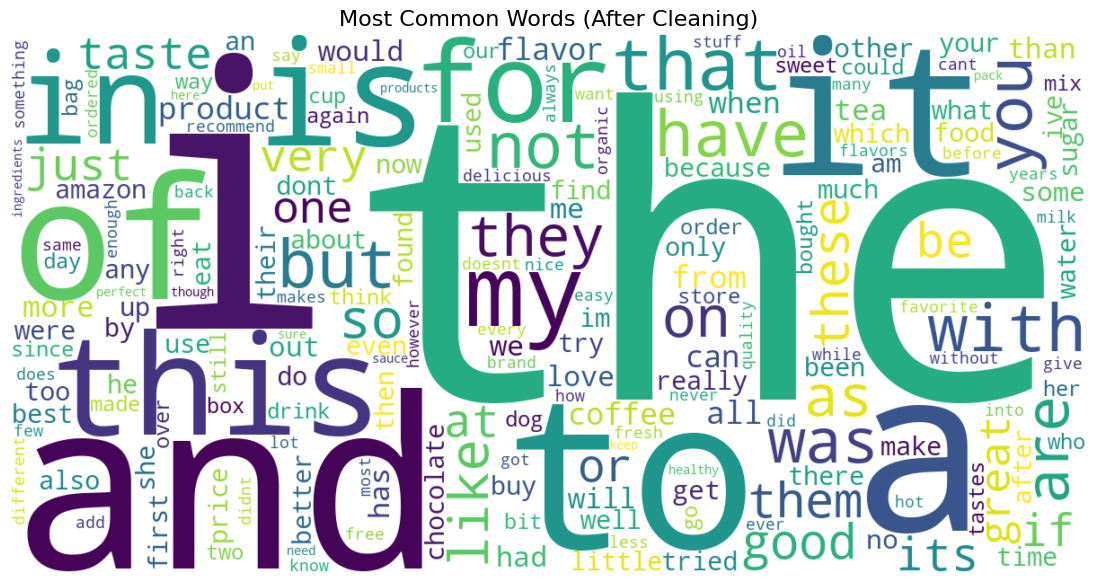

In [19]:
from collections import Counter
from wordcloud import WordCloud

counter = Counter()

for text in df['cleaned_text'].dropna():
    counter.update(str(text).split())

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    max_words=200,
    colormap='viridis'
).generate_from_frequencies(counter)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words (After Cleaning)', fontsize=16)
plt.show()

br is completely gone ✅ — but now notice something new. Look at the biggest words:
one, will, dont, much, even, though, now, still, thing — these are dominating but carry zero meaning for food reviews.
These are called stopwords — extremely common words that add no value to NLP analysis.

In [20]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = text.split()
    filtered = [w for w in words if w not in stop_words]
    return ' '.join(filtered)

df['cleaned_text'] = df['cleaned_text'].apply(remove_stopwords)
df['cleaned_summary'] = df['cleaned_summary'].apply(remove_stopwords)

# Verify
print("AFTER STOPWORD REMOVAL:", df['cleaned_text'].iloc[0][:200])

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\pragy\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


AFTER STOPWORD REMOVAL: bought several vitality canned dog food products found good quality product looks like stew processed meat smells better labrador finicky appreciates product better


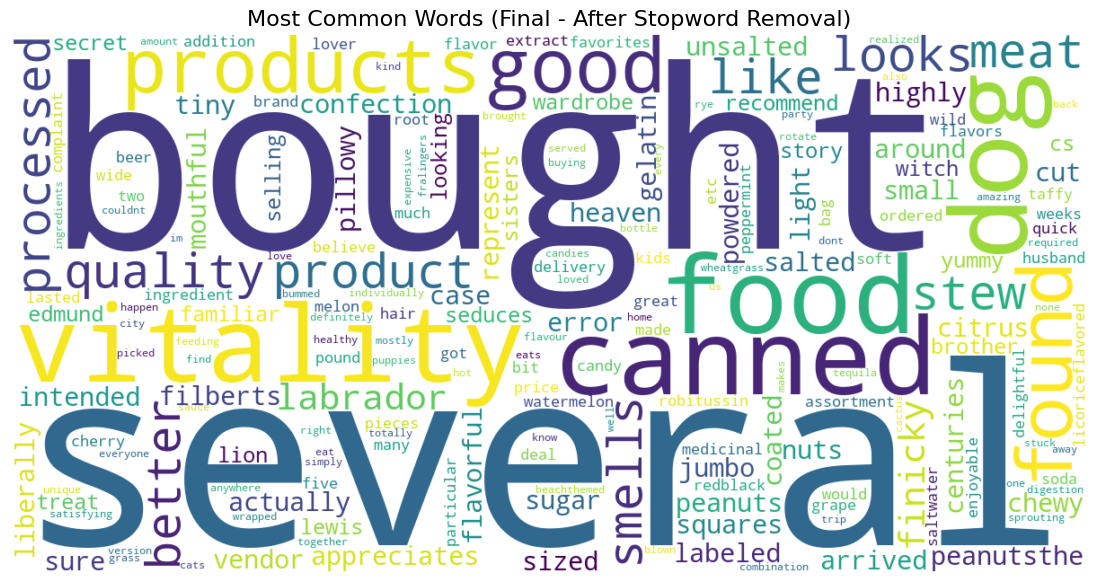

In [21]:
from wordcloud import WordCloud

# Build wordcloud directly without joining
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    max_words=200,
    colormap='viridis'
).generate_from_frequencies(
    {word: 1 for text in df['cleaned_text'].dropna() for word in str(text).split()}
)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words (Final - After Stopword Removal)', fontsize=16)
plt.show()

In [22]:
custom_stopwords = {
    'even', 'well', 'think', 'though', 'still', 'maybe', 
    'although', 'either', 'thats', 'dont', 'etc', 'thing',
    'really', 'much', 'also', 'actually', 'probably', 'almost',
    'every', 'everything', 'nothing', 'something', 'anything',
    'ive', 'im', 'its', 'nt', 'got', 'get', 'said', 'say',
    'come', 'came', 'way', 'made', 'make', 'used', 'use',
    'one', 'two', 'first', 'last', 'lot', 'little', 'bit',
    'along', 'around', 'back', 'put', 'need', 'sure', 'right',
    'left', 'long', 'since', 'fact', 'place', 'might', 'mean'
}

# Combine with NLTK stopwords
all_stopwords = stop_words.union(custom_stopwords)

def remove_all_stopwords(text):
    words = text.split()
    filtered = [w for w in words if w not in all_stopwords]
    return ' '.join(filtered)

df['cleaned_text'] = df['cleaned_text'].apply(remove_all_stopwords)
df['cleaned_summary'] = df['cleaned_summary'].apply(remove_all_stopwords)

print("FINAL TEXT:", df['cleaned_text'].iloc[0][:200])

FINAL TEXT: bought several vitality canned dog food products found good quality product looks like stew processed meat smells better labrador finicky appreciates product better


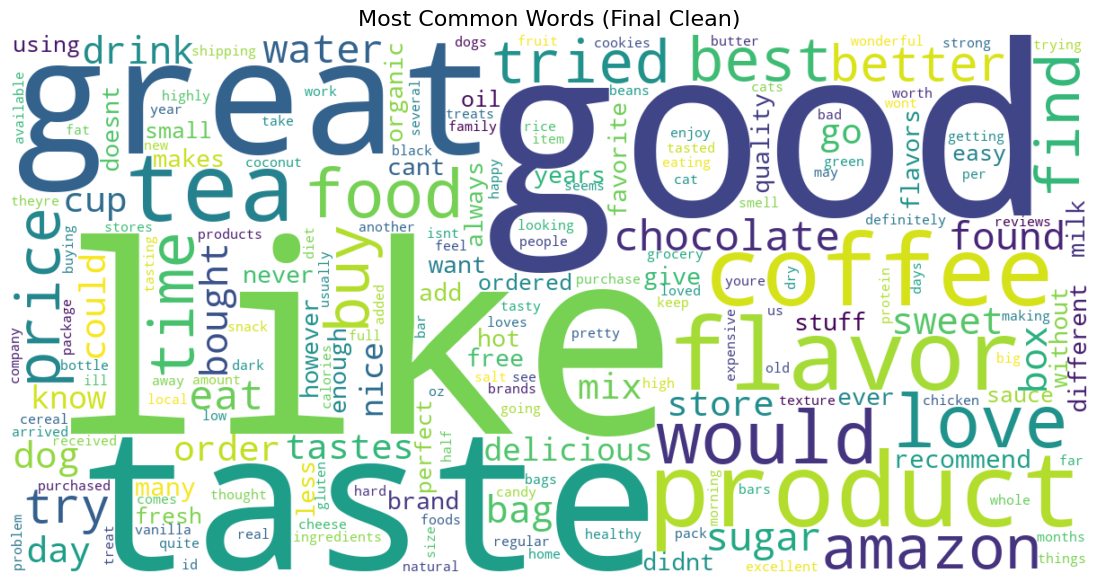

In [23]:
from collections import Counter
from wordcloud import WordCloud

counter = Counter()

for text in df['cleaned_text'].dropna():
    counter.update(str(text).split())

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    max_words=200,
    colormap='viridis'
).generate_from_frequencies(counter)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words (Final Clean)', fontsize=16)
plt.show()

In [24]:
df.to_csv('Reviews_cleaned.csv', index=False)
print("Cleaned data saved successfully!")
print(f"Shape: {df.shape}")

Cleaned data saved successfully!
Shape: (393933, 15)


In [25]:
df.columns

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text',
       'review_length', 'helpfulness_ratio', 'Year', 'cleaned_text',
       'cleaned_summary'],
      dtype='object')